# Your own sensor points, in 3D

**Question:** how much daylight reaches the facades of two buildings and the park in front
of them, over one year?

With your own sensor points you choose exactly where the values are: windows, a bench,
a playground. You get one value for each point. Here the points sit on the facades of the
Karlskirche and the Wien Museum (Vienna, Karlsplatz), and on a grid in Resselpark.

**Steps**
1. Make the building meshes (all buildings give shade).
2. Put sensor points on two facades and in the park, with a normal for each point.
3. Check the points on a plan before you pay.
4. Run daylight availability with `client.analyses.run_and_wait`.
5. Summarise each facade, and draw the points in 3D.

Own points are not an area run: the SDK sends one request and does not tile it.
Docs: [Bring your own sensors](https://infrared.city/docs/sdk/#bring-your-own-sensors).

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from infrared_sdk import InfraredClient, SolarModelRequest
from infrared_sdk.analyses.types import AnalysesName
from infrared_sdk.models import TimePeriod

import ir_site as site
import ir_view3d as v3

os.environ.setdefault("INFRARED_QUIET", "1")  # no SDK progress lines in the notebook
logging.getLogger("infrared_sdk.sdk").setLevel(logging.ERROR)  # no "default base URL" note
client = InfraredClient()  # reads INFRARED_API_KEY
OUT = Path("outputs")
DATA = Path("../sample-data/vienna-demo/scenarios/01-baseline")

## 1. Buildings

All 123 buildings go into the request. They give shade, but only the sensor points get values.
The frame is the same as in the other notebooks: metres, origin at the south-west corner.

In [2]:
footprints = site.read_geojson(DATA / "buildings.geojson")
polygon = site.polygon_around(footprints["features"], pad_m=30)
origin = site.origin_of(polygon)
buildings = site.buildings_from_geojson(footprints, origin)

## 2. Sensor points and normals

- **Facades:** one point for each 1 m x 1 m of wall, 0.3 m in front of the wall. The normal
  points out of the building, so the point "looks" at the street.
- **Park:** a 3 m grid, 1 m above the ground. The normal points up.

The limit is 300,000 points for each job.

In [3]:
TARGETS = {0: "Karlskirche", 1: "Wien Museum"}  # index in buildings.geojson
points, normals, groups = [], [], []
for index, name in TARGETS.items():
    feature = footprints["features"][index]
    p, n, wall = site.facade_sensors(site.footprint_xy(feature, origin),
                                     feature["properties"]["height_m"], spacing=1.0)
    points.append(p)
    normals.append(n)
    # compass bearing of each wall normal: 0 = north, 90 = east
    bearing = (np.degrees(np.arctan2(n[:, 0], n[:, 1])) + 360) % 360
    groups += [{"building": name, "wall": w, "bearing": b} for w, b in zip(wall, bearing)]

surfaces = site.read_geojson(DATA / "surfaces.geojson")
park = next(f for f in surfaces["features"] if f["properties"].get("name") == "Resselpark")
park_points = site.ground_sensors(site.footprint_xy(park, origin), spacing=3.0, z=1.0)
points.append(park_points)
normals.append(np.tile([0.0, 0.0, 1.0], (len(park_points), 1)))
groups += [{"building": "Resselpark", "wall": -1, "bearing": np.nan}] * len(park_points)

points, normals = np.vstack(points), np.vstack(normals)
groups = pd.DataFrame(groups)
print(groups["building"].value_counts().to_string())

building
Karlskirche    5126
Resselpark     3873
Wien Museum    2760


## 3. Check the points before you pay

A plan view shows if the points sit where you expect them: on the right buildings, outside
the walls, inside the park. A wrong frame (for example, the origin at the centre) shows here.

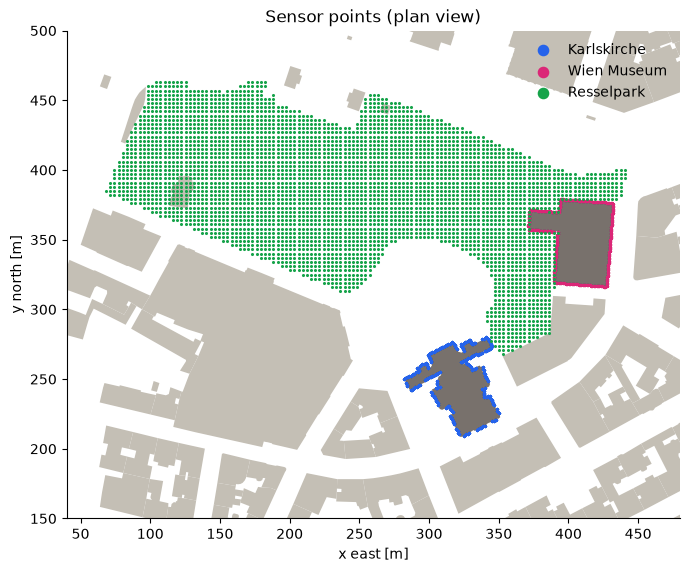

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
for i, f in enumerate(footprints["features"]):
    poly = site.footprint_xy(f, origin)
    x, y = poly.exterior.xy
    ax.fill(x, y, color="#c4bfb5" if i not in TARGETS else "#78716c", lw=0)
colors = {"Karlskirche": "#2563eb", "Wien Museum": "#db2777", "Resselpark": "#16a34a"}
for name, color in colors.items():
    m = (groups["building"] == name).to_numpy()
    ax.scatter(points[m, 0], points[m, 1], s=1.5, color=color, label=name)
ax.set(xlim=(40, 480), ylim=(150, 500), aspect="equal", xlabel="x east [m]", ylabel="y north [m]",
       title="Sensor points (plan view)")
ax.legend(frameon=False, markerscale=6, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

**What you see:** blue points ring the Karlskirche, pink points ring the Wien Museum, and the
green grid fills Resselpark. The points stand just outside the walls.

## 4. Run daylight availability

Daylight availability is the share of the time in a window when a point gets enough daylight,
from the sun and the sky. It needs a time window and a location, but no weather file.
The preview is local and free.

In [5]:
lon, lat = np.mean(polygon["coordinates"][0][:4], axis=0)
request = SolarModelRequest(
    analysis_type=AnalysesName.daylight_availability,
    latitude=lat,
    longitude=lon,
    time_period=TimePeriod(start_month=1, start_day=1, start_hour=8,
                           end_month=12, end_day=31, end_hour=18),
    geometries=buildings,
    sensor_points=points.tolist(),
    sensor_normals=normals.tolist(),
)
preview = client.analyses.preview_parts(request)
print(f"{len(points):,} points, jobs {preview.part_count}, cost {preview.estimated_cost_tokens} tokens")

11,759 points, jobs 1, cost 10 tokens


In [6]:
result = client.analyses.run_and_wait(request)
groups["value"] = np.asarray(result["output"], dtype=float)  # one value for each point, in order
print(f"{result['sensor-count']:,} values, {groups['value'].min():.0f} to {groups['value'].max():.0f} %")

11,759 values, 0 to 100 %


## 5. One value for each facade

Each wall gets the mean of its points. The bearing tells where the wall looks.

In [7]:
SECTORS = np.array(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
walls = groups[groups["wall"] >= 0].copy()
walls["faces"] = SECTORS[((walls["bearing"] + 22.5) // 45).astype(int) % 8]
summary = (walls.groupby(["building", "faces"])["value"].agg(["mean", "size"])
           .rename(columns={"mean": "daylight %", "size": "points (m²)"})
           .unstack(0).round(0))
summary = summary.reindex([s for s in SECTORS if s in summary.index])
summary.style.format(precision=0, na_rep="-")

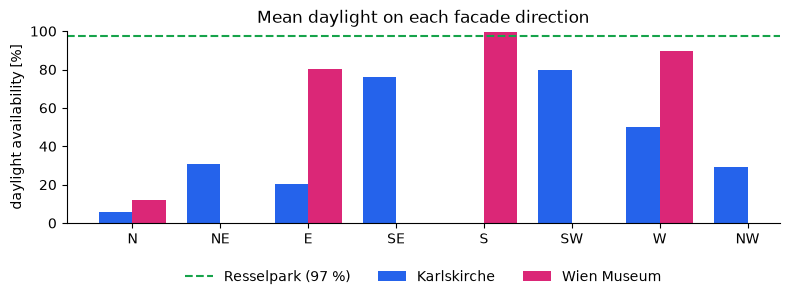

In [8]:
order = [s for s in SECTORS if s in walls["faces"].unique()]
fig, ax = plt.subplots(figsize=(8, 3.2))
for k, (name, color) in enumerate(list(colors.items())[:2]):
    mean = walls[walls["building"] == name].groupby("faces")["value"].mean().reindex(order)
    ax.bar(np.arange(len(order)) + (k - 0.5) * 0.38, mean, width=0.38, color=color, label=name)
park_mean = groups.loc[groups["building"] == "Resselpark", "value"].mean()
ax.axhline(park_mean, color=colors["Resselpark"], lw=1.5, ls="--", label=f"Resselpark ({park_mean:.0f} %)")
ax.set_xticks(range(len(order)), order)
ax.set(ylabel="daylight availability [%]", ylim=(0, 100), title="Mean daylight on each facade direction")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()

**What you see:** south walls get the highest values, and north walls the lowest (about 6 to
12 %). The best south facade is about as bright as the open park: a horizontal point in the open
sees the whole sky, a wall sees at most half of it.

## 6. The 3D view

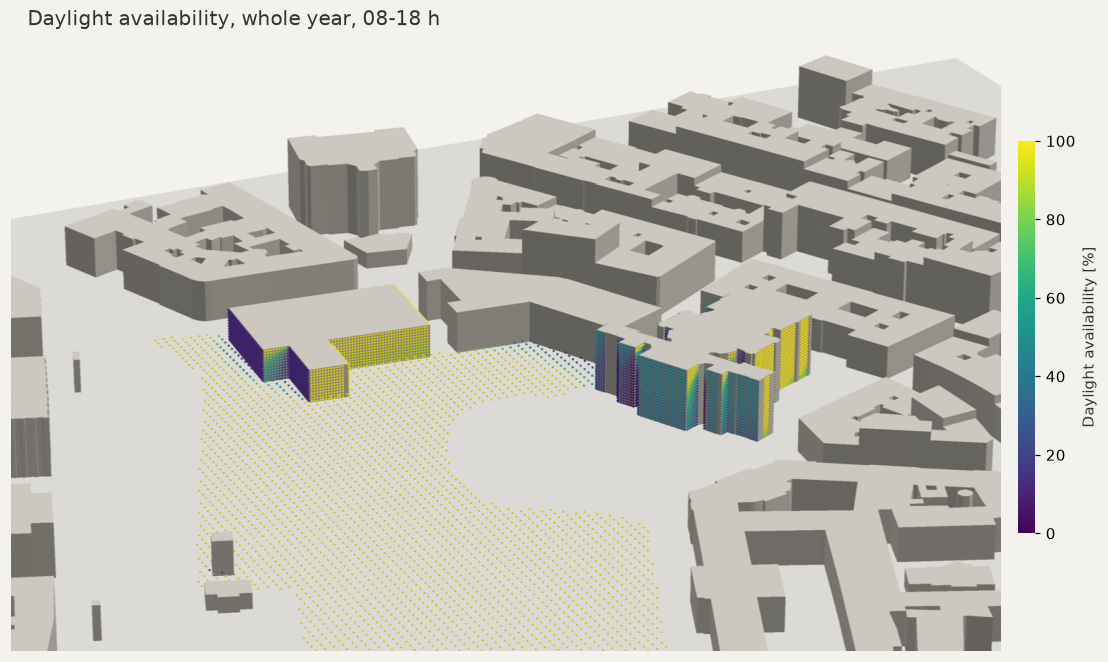

In [9]:
cloud = v3.points_cloud(points, groups["value"])
context = v3.mesh_from_dicts(buildings)
pl = v3.plotter()
v3.add_ground(pl, context.bounds, pad=20)
v3.add_meshes(pl, context)
v3.add_values(pl, cloud, cmap="viridis", clim=(0, 100), point_size=7)
v3.show(pl, OUT / "05_daylight_points.png", cmap="viridis", clim=(0, 100),
        label="Daylight availability [%]", title="Daylight availability, whole year, 08-18 h",
        azimuth=-115, elevation=24, zoom=4.0, focus=(370, 300, 8))

**What you see:** each dot is one sensor. The view looks east, from the park. The west and
south-west facades are bright; the north facades are dark. The park points are almost all
yellow: an open, horizontal point gets daylight almost all the time.

## Next steps

- Put the points on your window positions to compare floors or rooms.
- Use `SvfModelRequest` (sky view factor), `SolarRadiationModelRequest` or `direct-sun-hours` with the same points.
- For values on every facade and roof, use `analysis_surfaces` instead (see `04_solar_facades_3d.ipynb`).